# CCE Moorings - Temporal Scales Analysis in isopycnal coordinates

**Purpose**: Code for computing the mean autocorrelation function for scalar fields from CCE moorings.

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook: 

In [1]:
%matplotlib inline

Import python libraries

In [2]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
from netCDF4 import Dataset, num2date
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import cmocean
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.lines as mlines
import matplotlib.dates as mdates

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
import cartopy_figs as cart
from autocorr import compute_autocorr_optimize, compute_decor_scale_optimize
from spectra import spectrum1D_frequency, spectral_slope
from lsf import unweighted_lsf, compute_amp_phase, compute_amp_phase_unc, detrend
from structure_functions import compute_structure_function
from var_analysis import variance_scale_analysis_1D_masked

Set data analysis parameters

In [3]:
# Set processing parameters
option_mooring       = 'CCE2' # Specifies which mooring will analyzed. 
option_obs           = 'CTD'  # Specifies the observational instrumentation to process. Options include: 'CTD'
option_grid          = 1      # Specifies whether the gridded product or the nearest neighbor iso-correct approach is used

# Set time and space parameters
T               = 1*(60)*(60)                         # Spcifies the time interval for model run. Units: seconds
estimator       = 'biased'                            # Specifies the approach for estimating the autocorrelation function  
start_time      = datetime(2020, 1, 1, 0, 0, 0)       # Specifies the start time of the event period 
end_time        = datetime(2021, 12, 31, 23, 59, 59)  # Specifies the end time of the event period       
event_time_bnds = [start_time, end_time]              # Specifies the event period

# Set path to project directory
PATH = "/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/AirSeaCoupling"
PATH_bathy  = ROOT + 'AirSeaCoupling/data/bathymetry/'

# Set plotting parameters 
fontsize = 14

#----------------------------------#
# Note - Time Periods for CTD Processing
#----------------------------------#
#
# CTD Processing (gridded)
# --------------
#   CCE1 - datetime(2016, 1, 1, 0, 0, 0) to datetime(2017, 12, 31, 23, 59, 59) 
#   CCE2 - datetime(2020, 1, 1, 0, 0, 0) to datetime(2021, 12, 31, 23, 59, 59) 

Load CCE processed data

In [4]:
# Set the file name and read in the data file
if option_grid == 1:
    filename_CCE = PATH + "/data/CCE/" + option_mooring + "/" + option_obs + "/" + option_mooring + "_" + option_obs + "_" + str(start_time.year) + str(start_time.month) + str(start_time.day) +  "-" + str(end_time.year) + str(end_time.month) + str(end_time.day) + "_intermediate_gridded_data.nc"
else:
    filename_CCE = PATH + "/data/CCE/" + option_mooring + "/" + option_obs + "/" + option_mooring + "_" + option_obs + "_" + str(start_time.year) + str(start_time.month) + str(start_time.day) +  "-" + str(end_time.year) + str(end_time.month) + str(end_time.day) + "_intermediate_data.nc"
nc_CCE = Dataset(filename_CCE, 'r')

# Extract data variables
iso             = nc_CCE.variables['isopycnal'][:]
time            = num2date(nc_CCE.variables['time'][:], nc_CCE.variables['time'].units)
lon             = nc_CCE.variables['LON'][:]
lat             = nc_CCE.variables['LAT'][:]

z_sig           = nc_CCE.variables['Z_sig'][:]
sal_sig         = nc_CCE.variables['ASal_sig'][:]
temp_sig        = nc_CCE.variables['CTemp_sig'][:]

# Convert cftime.DatetimeGregorian to Python datetime objects
time_dt = np.array([datetime(d.year, d.month, d.day, d.hour, d.minute, d.second) for d in time])

Preform scale analysis

In [5]:
# Set parameters
niso,ntime = np.shape(temp_sig)
lag = ntime
w1, w2 = [(2*np.pi)/31557600, (1/2)*(2*np.pi)/31557600]      # Radian Frequency for annual and semi-annual cycles. Units: rad/sec

# Compute scales array for variance analysis and convert to hours (number of samples)
scales_days = np.logspace(np.log10(0.5),np.log10(365),40)    # units: days
scales = scales_days*24                                      # units: # of samples

# Convert to interger values 
nscales = len(scales)
scales_int = np.array([int(scales[i]) for i in range(nscales)])

#Convert to seconds since start time
t0 = time[0]
time_elapsed = np.array([(t - t0).total_seconds() for t in time])

#--- Temperature --- #

# Initialize arrays 
autocorr_temp       = np.zeros((ntime,niso))
time_scale_temp     = np.zeros((ntime,niso))
Lt_temp             = np.zeros((niso))
V_temp              = np.zeros((nscales,niso))
L_temp              = np.zeros((nscales,niso))
p_temp              = np.zeros((niso))

# Set counter
cn_iso = 0 

# Loop through isopycnals
for it in range(0,niso):
    
    # Set progress bar
    progress = (it) / (len(iso))
    sys.stdout.write(f"\rProgress: {progress:.1%}")
    sys.stdout.flush()
        
    # Initialize the ith time series 
    data_ts = temp_sig[it,:]

    # Remove annual and semi-annual cycle 
    hfit, x_data, x_data_sigma, _ = unweighted_lsf(data_ts, time_elapsed, parameters = 2, freqs = np.array([w1,w2]), sigma = None)
    data_ts_rm = data_ts - hfit

    # Detrend data record 
    data_dt = detrend(data_ts_rm, time_elapsed, mean = 0)

    # Compute autocorrelation function
    autocorr_temp[:,cn_iso], _, _, _, time_scale_temp[:,cn_iso], _ = compute_autocorr_optimize(data_dt, time_elapsed, lag, estimator, 0)

    # Compute the decorrelation scale
    Lt_temp[cn_iso] = compute_decor_scale_optimize(autocorr_temp[:,cn_iso],time_scale_temp[:,cn_iso],T,'unbiased',0)

    # Compute scale variance and patchiness
    L_temp[:,cn_iso], V_temp[:,cn_iso], p_temp[cn_iso], _ = variance_scale_analysis_1D_masked(data_dt, scales=scales_int, fit_range=None, overlap=0.0, return_windows=False)

    # Set longitude counter
    cn_iso = cn_iso + 1

# Convert time scale to units of days
Lt_temp_days = Lt_temp*(1/60)*(1/60)*(1/24)

#--- Salinity ---# 

# Initialize arrays 
autocorr_sal       = np.zeros((ntime,niso))
time_scale_sal     = np.zeros((ntime,niso))
Lt_sal             = np.zeros((niso))
V_sal              = np.zeros((nscales,niso))
L_sal              = np.zeros((nscales,niso))
p_sal              = np.zeros((niso))

# Set counter
cn_iso = 0 

# Loop through isopycnals 
for it in range(0,niso):
    
    # Set progress bar
    progress = (it) / (len(iso))
    sys.stdout.write(f"\rProgress: {progress:.1%}")
    sys.stdout.flush()
        
    # Initialize the ith time series 
    data_ts = sal_sig[it,:]

    # Remove annual and semi-annual cycle 
    hfit, x_data, x_data_sigma, _ = unweighted_lsf(data_ts, time_elapsed, parameters = 2, freqs = np.array([w1,w2]), sigma = None)
    data_ts_rm = data_ts - hfit

    # Detrend data record 
    data_dt = detrend(data_ts_rm, time_elapsed, mean = 0)

    # Compute autocorrelation function
    autocorr_sal[:,cn_iso], _, _, _, time_scale_sal[:,cn_iso], _ = compute_autocorr_optimize(data_dt, time_elapsed, lag, estimator, 0)

    # Compute the decorrelation scale
    Lt_sal[cn_iso] = compute_decor_scale_optimize(autocorr_sal[:,cn_iso],time_scale_sal[:,cn_iso],T,'unbiased',0)

    # Compute scale variance and patchiness
    L_sal[:,cn_iso], V_sal[:,cn_iso], p_sal[cn_iso], _ = variance_scale_analysis_1D_masked(data_dt, scales=scales_int, fit_range=None, overlap=0.0, return_windows=False)

    # Set longitude counter
    cn_iso = cn_iso + 1

# Convert time scale to units of days
Lt_sal_days = Lt_sal*(1/60)*(1/60)*(1/24)

#--- Isopycnal Depth ---# 

# Initialize arrays 
autocorr_z       = np.zeros((ntime,niso))
time_scale_z     = np.zeros((ntime,niso))
Lt_z             = np.zeros((niso))
V_z              = np.zeros((nscales,niso))
L_z              = np.zeros((nscales,niso))
p_z              = np.zeros((niso))

# Set counter
cn_iso = 0 

# Loop through isos 
for it in range(0,niso):
    
    # Set progress bar
    progress = (it) / (len(iso))
    sys.stdout.write(f"\rProgress: {progress:.1%}")
    sys.stdout.flush()
        
    # Initialize the ith time series 
    data_ts = z_sig[it,:]

    # Remove annual and semi-annual cycle 
    hfit, x_data, x_data_sigma, _ = unweighted_lsf(data_ts, time_elapsed, parameters = 2, freqs = np.array([w1,w2]), sigma = None)
    data_ts_rm = data_ts - hfit

    # Detrend data record 
    data_dt = detrend(data_ts_rm, time_elapsed, mean = 0)

    # Compute autocorrelation function
    autocorr_z[:,cn_iso], _, _, _, time_scale_z[:,cn_iso], _ = compute_autocorr_optimize(data_dt, time_elapsed, lag, estimator, 0)

    # Compute the decorrelation scale
    Lt_z[cn_iso] = compute_decor_scale_optimize(autocorr_z[:,cn_iso],time_scale_z[:,cn_iso],T,'unbiased',0)

    # Compute scale variance and patchiness
    L_z[:,cn_iso], V_z[:,cn_iso], p_z[cn_iso], _ = variance_scale_analysis_1D_masked(data_dt, scales=scales_int, fit_range=None, overlap=0.0, return_windows=False)

    # Set longitude counter
    cn_iso = cn_iso + 1

# Convert time scale to units of days
Lt_z_days = Lt_z*(1/60)*(1/60)*(1/24)


Progress: 91.7%

Compute the mean profiles for temperature, salinity, and density

In [6]:
# Set the number of time steps 
_,ntime_temp = np.shape(temp_sig)
_,ntime_sal = np.shape(sal_sig)
_,ntime_rho = np.shape(z_sig)

# Compute the time mean, standard deviation, and variance profiles
meanTemp = np.ma.mean(temp_sig,axis=1) 
meanSal  = np.ma.mean(sal_sig,axis=1) 
meanZ    = np.ma.mean(z_sig,axis=1) 

stdTemp  = np.ma.std(temp_sig,axis=1,ddof=1)
stdSal   = np.ma.std(sal_sig,axis=1,ddof=1)
stdZ     = np.ma.std(z_sig,axis=1,ddof=1)

varTemp  = np.ma.var(temp_sig,axis=1,ddof=1)
varSal   = np.ma.var(sal_sig,axis=1,ddof=1)
varZ     = np.ma.var(z_sig,axis=1,ddof=1)

# Compute the number of degrees of freedom at each site
T_days = T*(1/60)*(1/60)*(1/24)
nd_temp, nd_sal, nd_z = Lt_temp_days/T_days, Lt_sal_days/T_days, Lt_z_days/T_days
Neff_temp = ntime/(nd_temp)
Neff_sal  = ntime/(nd_sal)
Neff_z    = ntime/(nd_z)

# Compute the standard error of the mean and variance
stdmTemp = stdTemp/np.sqrt(Neff_temp)
stdmSal  = stdSal/np.sqrt(Neff_sal)
stdmZ    = stdZ/np.sqrt(Neff_z)

stdvTemp = varTemp * np.sqrt(2/(Neff_temp-1))
stdvSal  = varSal * np.sqrt(2/(Neff_sal-1))
stdvZ  = varZ * np.sqrt(2/(Neff_z-1))

Plot a comparison of the decorrelation scales from each of the variables

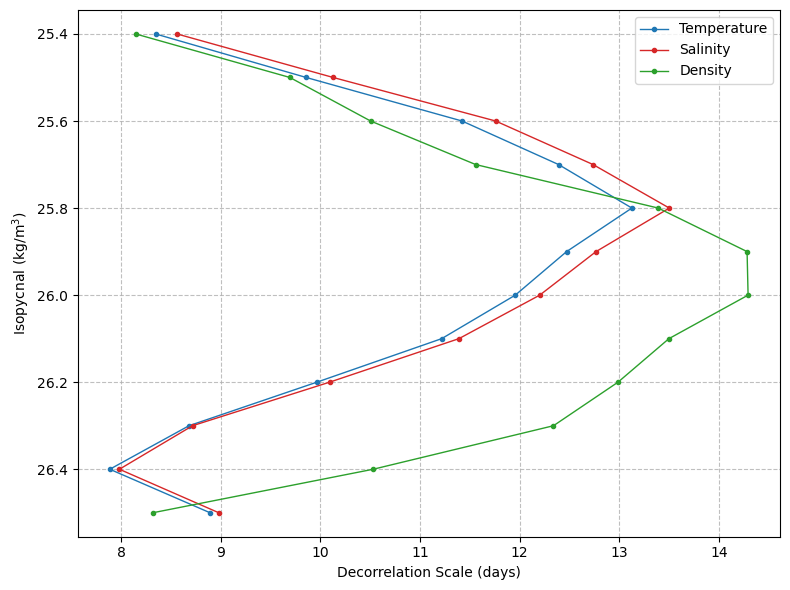

In [7]:
# Create the figure
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

# Plot the decorrelation length scale
ax.plot(Lt_temp_days, iso, '.-', color='tab:blue', linewidth=1,label='Temperature')
ax.plot(Lt_sal_days, iso, '.-', color='tab:red', linewidth=1, label='Salinity')
ax.plot(Lt_z_days, iso, '.-', color='tab:green', linewidth=1, label='Density')

# Set figure attributes
ax.set_xlabel(r'Decorrelation Scale (days)')
ax.set_ylabel(r"Isopycnal (kg/m$^3$)")
ax.grid(True,linestyle='--',alpha=0.8)
ax.legend()

# Reverse the direction of the x-axis 
ax.invert_yaxis() 

# Display figure
plt.tight_layout()
plt.show()

Plot mean profile

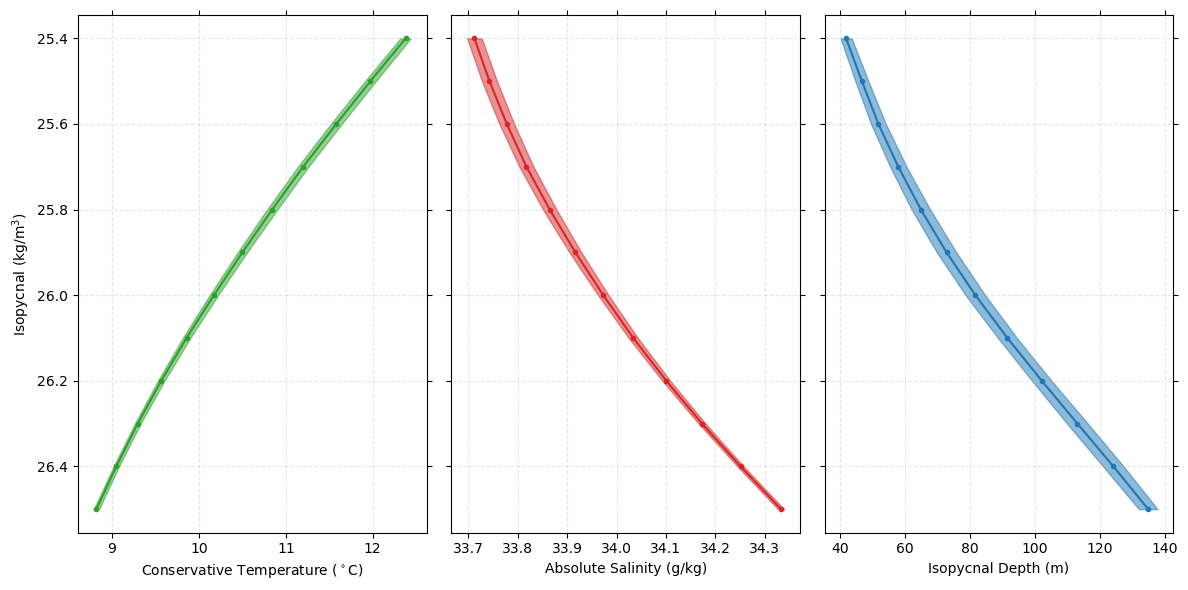

In [8]:
# Create figure
fig,axes = plt.subplots(1,3,figsize=(12, 6))
ax1,ax2,ax3 = axes.flatten()

#--- Subplot 1 ---# 

# Plot mean profiles 
ax1.plot(meanTemp,iso,'.-',color='tab:green')

# Plot standard error of the mean profiles
ax1.fill_betweenx(iso, meanTemp - stdmTemp, meanTemp + stdmTemp, color='tab:green', alpha=0.5)

# Set axis attributes
ax1.set_xlabel(r'Conservative Temperature ($^\circ$C)')
ax1.set_ylabel(r"Isopycnal (kg/m$^3$)")
ax1.invert_yaxis()
ax1.grid(True,linestyle='--',alpha=0.3)
ax1.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)

#--- Subplot 2 ---# 

# Plot mean profiles
ax2.plot(meanSal,iso,'.-',color='tab:red')

# Plot standard error of the mean profiles
ax2.fill_betweenx(iso, meanSal - stdmSal, meanSal + stdmSal, color='tab:red', alpha=0.5)

# Set axis attributes
ax2.set_xlabel('Absolute Salinity (g/kg)')
ax2.set_yticklabels([])
ax2.invert_yaxis()
ax2.grid(True,linestyle='--',alpha=0.3)
ax2.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)

#--- Subplot 3 ---# 

# Plot mean profiles
ax3.plot(meanZ,iso,'.-',color='tab:blue')

# Plot standard error of the mean profiles
ax3.fill_betweenx(iso, meanZ - stdmZ, meanZ + stdmZ, color='tab:blue', alpha=0.5)

# Set axis attributes
ax3.set_xlabel(r'Isopycnal Depth (m)')
ax3.set_yticklabels([])
ax3.invert_yaxis()
ax3.grid(True,linestyle='--',alpha=0.3)
ax3.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)

# Show figure
plt.tight_layout()
plt.show()


Plot the variance profiles for temperature, salinity, and density

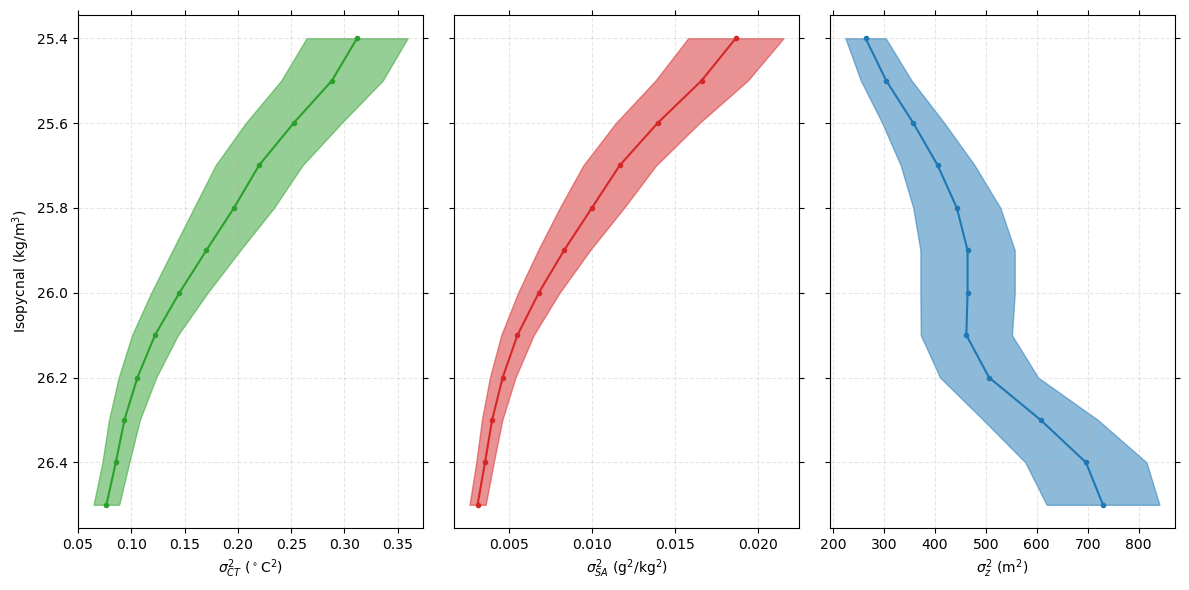

In [9]:
# Create figure
fig,axes = plt.subplots(1,3,figsize=(12, 6))
ax1,ax2,ax3 = axes.flatten()

#--- Subplot 1 ---# 

# Plot mean profiles 
ax1.plot(varTemp,iso,'.-',color='tab:green')

# Plot standard error of the mean profiles
ax1.fill_betweenx(iso, varTemp - stdvTemp, varTemp + stdvTemp, color='tab:green', alpha=0.5)

# Set axis attributes
ax1.set_xlabel(r'$\sigma^2_{CT}$ ($^\circ$C$^2$)')
ax1.set_ylabel(r"Isopycnal (kg/m$^3$)")
ax1.invert_yaxis()
ax1.grid(True,linestyle='--',alpha=0.3)
ax1.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)

#--- Subplot 2 ---# 

# Plot mean profiles
ax2.plot(varSal,iso,'.-',color='tab:red')

# Plot standard error of the mean profiles
ax2.fill_betweenx(iso, varSal - stdvSal, varSal + stdvSal, color='tab:red', alpha=0.5)

# Set axis attributes
ax2.set_xlabel(r'$\sigma^2_{SA}$ (g$^2$/kg$^2$)')
ax2.set_yticklabels([])
ax2.invert_yaxis()
ax2.grid(True,linestyle='--',alpha=0.3)
ax2.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)

#--- Subplot 3 ---# 

# Plot mean profiles
ax3.plot(varZ,iso,'.-',color='tab:blue')

# Plot standard error of the mean profiles
ax3.fill_betweenx(iso, varZ - stdvZ, varZ + stdvZ, color='tab:blue', alpha=0.5)

# Set axis attributes
ax3.set_xlabel(r'$\sigma^2_{z}$ (m$^2$)')
ax3.set_yticklabels([])
ax3.invert_yaxis()
ax3.grid(True,linestyle='--',alpha=0.3)
ax3.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)

# Show figure
plt.tight_layout()
plt.show()


Save data into an intermediate product npz file

In [10]:
#--- Autocorrelation and decorrelation scales ---# 

# Check if file exists, then delete it
file_path = PATH + "/data/CCE/" + option_mooring + "/" + option_obs + "/" + option_mooring + "_" + option_obs + "_" + str(start_time.year) + str(start_time.month) + str(start_time.day) +  "-" + str(end_time.year) + str(end_time.month) + str(end_time.day) + "_scale_on_sig_data_gridded.npz"
if os.path.exists(file_path):
    os.remove(file_path)

# Set metadata
metadata = {
    'description': 'Temporal decorrelation scale in isopycnal coordinate from the ' + option_mooring + ' mooring for the ' + option_obs + '. Here, the annual and semi-annual cycles are removed before computing the decorrelation scale.',
    'source': option_mooring + 'mooring',
    'coordinates units': 'hr'
}

# Save data arrays and metadata to a .npz file
np.savez(file_path, 
        autocorr_temp      = autocorr_temp,
        autocorr_sal       = autocorr_sal,
        autocorr_z         = autocorr_z,
        time_scale_temp    = time_scale_temp,  # Units: seconds
        time_scale_sal     = time_scale_sal,   # Units: seconds
        time_scale_z       = time_scale_z,     # Units: seconds
        Lt_temp            = Lt_temp_days,     # Units: days
        Lt_sal             = Lt_sal_days,      # Units: days
        Lt_z               = Lt_z_days,        # Units: days
        V_temp             = V_temp,           # Units: (deg C)^2
        V_sal              = V_sal,            # Units: (g/kg)^2
        V_z                = V_z,              # Units: (kg/m^3)^2
        p_temp             = p_temp, 
        p_sal              = p_sal, 
        p_z                = p_z, 
        L_temp             = L_temp,           # Units: days
        L_sal              = L_sal,            # Units: days
        L_z                = L_z,              # Units: days
        meanTemp_profile   = meanTemp, 
        meanSal_profile    = meanSal, 
        meanZ_profile      = meanZ, 
        varTemp_profile    = varTemp, 
        varSal_profile     = varSal, 
        varZ_profile       = varZ,
        stdmTemp_profile   = stdmTemp, 
        stdmSal_profile    = stdmSal, 
        stdmZ_profile      = stdmZ,  
        stdvTemp_profile   = stdvTemp, 
        stdvSal_profile    = stdvSal, 
        stdvZ_profile      = stdvZ, 
        lon                = lon,
        lat                = lat,
        isopycnal          = iso,
        metadata           = metadata
        )